In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import statsmodels.formula.api as smf

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_predict
from sklearn.neighbors import NearestNeighbors

In [2]:
# ============================================================
# CARREGAMENTO DA BASE PRINCIPAL DA AULA
# ============================================================
# O arquivo "aula03_completo.csv" contém os microdados utilizados
# na aula para construir o tratamento, selecionar as covariáveis
# e estimar o nosso propensity score.

dados_brutos = pd.read_csv("aula03_completo.csv")

# ------------------------------------------------------------
# Conferência inicial
# ------------------------------------------------------------
# Verificamos:
# 1. número de observações (linhas) e variáveis (colunas);
# 2. primeiras cinco observações;
# 3. lista completa das variáveis disponíveis.
#
# Neste momento não faremos nenhuma transformação na base.

print("Dimensões da base:")
print(dados_brutos.shape)

print("\nPrimeiras observações:")
display(dados_brutos.head())

print("\nColunas disponíveis:")
print(dados_brutos.columns.tolist())

Dimensões da base:
(56367, 28)

Primeiras observações:


,cod_dtm,s00a1,s02af,age,s02ad,s02a17,s02a21,s02a10,s02a5,s03a2,...,source,educ_chefe,n_moradores,n_familias,n_comodos,n_dormitorios,n_banheiros,agua_canalizada,mae_resp_le,estrato_amostral
0,1,11.0,52.0,52.232717,1.0,3.0,4.0,2.0,1.0,5.0,...,1.0,NaN,4.0,1.0,4.0,1.0,0.0,NaN,2.0,beneficiario
1,1,11.0,33.0,33.911020,2.0,2.0,4.0,1.0,2.0,3.0,...,1.0,NaN,4.0,1.0,4.0,1.0,0.0,NaN,2.0,beneficiario
2,1,11.0,10.0,10.225873,1.0,2.0,NaN,2.0,3.0,3.0,...,1.0,NaN,4.0,1.0,4.0,1.0,0.0,NaN,2.0,beneficiario
3,1,11.0,8.0,8.399726,1.0,2.0,NaN,2.0,3.0,3.0,...,1.0,NaN,4.0,1.0,4.0,1.0,0.0,NaN,2.0,beneficiario
4,2,11.0,63.0,63.611225,2.0,NaN,NaN,NaN,NaN,NaN,...,NaN,3.0,5.0,1.0,6.0,2.0,1.0,1.0,1.0,NaN



Colunas disponíveis:
['cod_dtm', 's00a1', 's02af', 'age', 's02ad', 's02a17', 's02a21', 's02a10', 's02a5', 's03a2', 's03a22', 's03a24', 'attend_now', 'dropout', 'p_attend7', 'if_miss30', 'grade_now', 'educ', 'source', 'educ_chefe', 'n_moradores', 'n_familias', 'n_comodos', 'n_dormitorios', 'n_banheiros', 'agua_canalizada', 'mae_resp_le', 'estrato_amostral']


In [3]:
# Carrega os escores oficiais
pscores = pd.read_csv("pscores_completo.csv")

# Conferência inicial
print(pscores.shape)
display(pscores.head())
print(pscores.columns.tolist())

(15426, 7)


,cod_dtm,tr1,pscore_tr1,tr2r2,pscore_tr2r2,weight,region
0,1,NaN,0.412314,NaN,0.524052,1156.1277,1.0
1,2,NaN,0.289960,NaN,0.303525,1052.6385,1.0
2,3,NaN,0.245186,NaN,0.513176,955.4703,1.0
3,4,NaN,0.757802,NaN,0.727262,1242.2445,2.0
4,5,NaN,NaN,NaN,NaN,696.5632,1.0


['cod_dtm', 'tr1', 'pscore_tr1', 'tr2r2', 'pscore_tr2r2', 'weight', 'region']


Correlação entre os escores oficiais:
              pscore_tr1  pscore_tr2r2
pscore_tr1      1.000000      0.664384
pscore_tr2r2    0.664384      1.000000


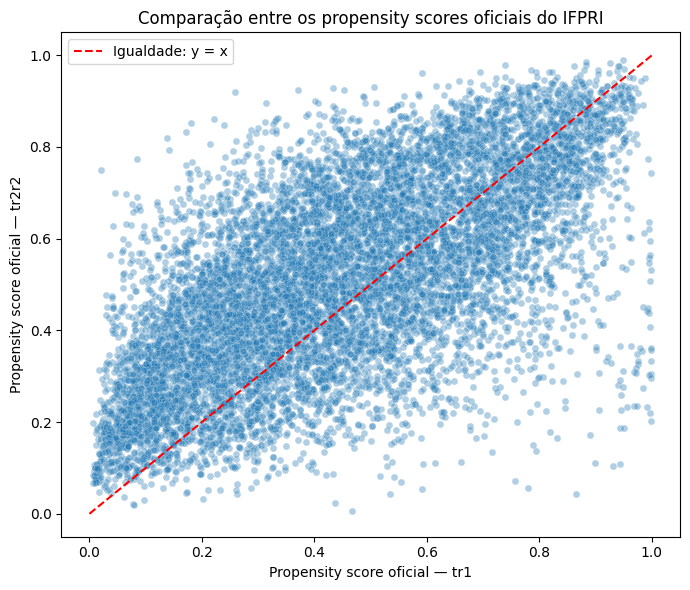

In [4]:
# Calcula a correlação entre as duas definições oficiais
corr_oficiais = pscores[["pscore_tr1", "pscore_tr2r2"]].corr()

print("Correlação entre os escores oficiais:")
print(corr_oficiais)

# Cria a figura
plt.figure(figsize=(7, 6))

# Gráfico de dispersão:
# cada ponto representa uma observação da base
sns.scatterplot(
    data=pscores,
    x="pscore_tr1",
    y="pscore_tr2r2",
    alpha=0.35,
    s=25
)

# Linha de referência y = x.
# Se os dois escores fossem idênticos, todos os pontos
# estariam exatamente sobre essa linha.
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="red",
    linewidth=1.5,
    label="Igualdade: y = x"
)

# Identificação dos eixos e título
plt.xlabel("Propensity score oficial — tr1")
plt.ylabel("Propensity score oficial — tr2r2")
plt.title("Comparação entre os propensity scores oficiais do IFPRI")

plt.legend()
plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# CRIAÇÃO DA VARIÁVEL DE TRATAMENTO
# ============================================================
# Aqui eu construo o tratamento no nível do domicílio.
#
# Uma criança é considerada tratada quando vive em um domicílio
# em que pelo menos uma pessoa é titular do cartão do Bolsa Família.
#
# A variável s02a10 identifica essa condição individualmente.
# Por isso, eu agrupo pelo código do domicílio (cod_dtm) e verifico
# se existe pelo menos uma observação com s02a10 igual a 1.

dados = dados_brutos.copy()

trat_dom = (
    dados.groupby("cod_dtm")["s02a10"]
    .apply(lambda s: int((s == 1).any()))
    .rename("D")
)

# Aqui eu junto a classificação do tratamento de volta à base individual.
# Assim, todas as pessoas do mesmo domicílio recebem o mesmo valor de D.

dados = dados.merge(
    trat_dom,
    on="cod_dtm",
    how="left"
)

# Por fim, eu confiro se reproduzi a mesma distribuição apresentada na aula.

print("Distribuição do tratamento D:")
print(dados["D"].value_counts())

Distribuição do tratamento D:
D
1    34437
0    21930
Name: count, dtype: int64


In [6]:
from sklearn.linear_model import LogisticRegression

# ============================================================
# PREPARAÇÃO DA AMOSTRA PARA ESTIMAR O NOSSO PROPENSITY SCORE
# ============================================================
# Aqui eu crio as mesmas variáveis derivadas usadas na aula
# e seleciono apenas a amostra necessária para estimar o escore.

# Crio a variável indicadora de sexo feminino
dados["feminino"] = (dados["s02ad"] == 2).astype(int)

# Crio a variável indicadora de acesso à água canalizada
dados["agua"] = (dados["agua_canalizada"] == 1).astype(int)

# Defino as sete covariáveis usadas no propensity score da aula
COVARIAVEIS = [
    "s02af",
    "feminino",
    "educ_chefe",
    "n_moradores",
    "n_comodos",
    "n_dormitorios",
    "agua"
]

# Aqui eu mantenho apenas crianças de 6 a 17 anos
# com informação observada para o desfecho
dados_ps = dados[
    dados["s02af"].between(6, 17)
    & dados["p_attend7"].notna()
].copy()

# Aqui eu retiro observações com valores ausentes
# em alguma das sete covariáveis
dados_ps = dados_ps.dropna(subset=COVARIAVEIS)

# ============================================================
# ESTIMAÇÃO DO PROPENSITY SCORE
# ============================================================
# O nosso propensity score é estimado por regressão logística,
# usando D como variável dependente e as sete covariáveis como X.

X = dados_ps[COVARIAVEIS]
y = dados_ps["D"]

modelo_ps = LogisticRegression(
    max_iter=1000
)

modelo_ps.fit(X, y)

# Aqui eu guardo, para cada observação, a probabilidade estimada
# de pertencer ao grupo tratado.
dados_ps["pscore_nosso"] = modelo_ps.predict_proba(X)[:, 1]

# Faço uma conferência rápida do tamanho da amostra
# e da distribuição do escore estimado.
print("Dimensões da amostra analítica:", dados_ps.shape)

print("\nDistribuição do tratamento:")
print(dados_ps["D"].value_counts())

print("\nResumo do nosso propensity score:")
print(dados_ps["pscore_nosso"].describe())

Dimensões da amostra analítica: (7805, 32)

Distribuição do tratamento:
D
1    5572
0    2233
Name: count, dtype: int64

Resumo do nosso propensity score:
count    7805.000000
mean        0.713901
std         0.085791
min         0.319453
25%         0.667790
50%         0.718233
75%         0.767025
max         0.923736
Name: pscore_nosso, dtype: float64


Número de observações utilizadas na comparação:
7453

Correlação entre o nosso escore e o pscore_tr2r2:
              pscore_nosso  pscore_tr2r2
pscore_nosso      1.000000      0.268746
pscore_tr2r2      0.268746      1.000000


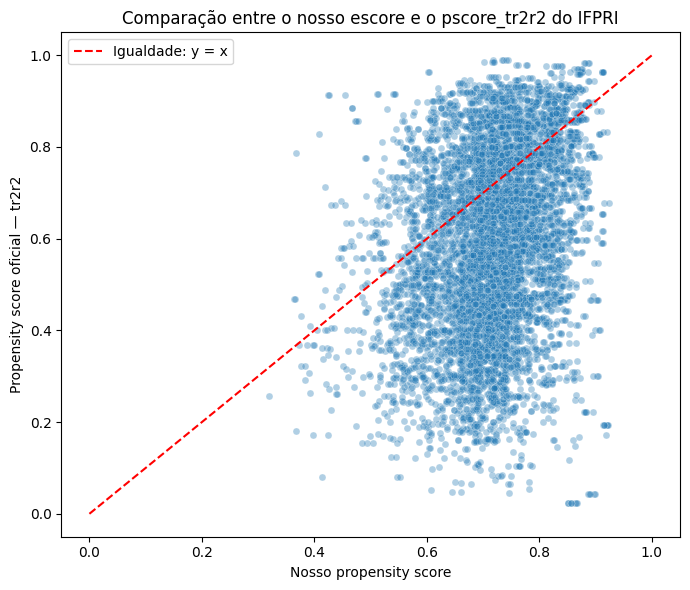

In [7]:
# ============================================================
# COMPARAÇÃO DO NOSSO ESCORE COM O PSCORE_TR2R2 DO IFPRI
# ============================================================
# Aqui eu junto à minha amostra o segundo propensity score
# oficial disponibilizado pelo IFPRI.
#
# Faço a junção por cod_dtm, que é o identificador comum
# entre a base utilizada na aula e a base de escores oficiais.

comparacao = dados_ps.merge(
    pscores[["cod_dtm", "pscore_tr2r2"]],
    on="cod_dtm",
    how="left"
)

# Para esta comparação, eu mantenho apenas as observações
# para as quais o IFPRI possui pscore_tr2r2 disponível.
comparacao = comparacao.dropna(subset=["pscore_tr2r2"])

# ============================================================
# CORRELAÇÃO ENTRE OS DOIS ESCORES
# ============================================================
# Aqui eu calculo a correlação de Pearson para verificar
# em que medida o nosso escore e o pscore_tr2r2 variam juntos.

correlacao = comparacao[
    ["pscore_nosso", "pscore_tr2r2"]
].corr()

print("Número de observações utilizadas na comparação:")
print(len(comparacao))

print("\nCorrelação entre o nosso escore e o pscore_tr2r2:")
print(correlacao)

# ============================================================
# GRÁFICO DE DISPERSÃO
# ============================================================
# Cada ponto representa uma observação da amostra.
# No eixo horizontal está o nosso propensity score e,
# no eixo vertical, o pscore_tr2r2 oficial do IFPRI.

plt.figure(figsize=(7, 6))

sns.scatterplot(
    data=comparacao,
    x="pscore_nosso",
    y="pscore_tr2r2",
    alpha=0.35,
    s=25
)

# Acrescento a linha y = x para facilitar a visualização
# da concordância entre os dois escores.
# Quanto mais próximos dessa linha estiverem os pontos,
# mais semelhantes são os valores atribuídos pelos dois escores.

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="red",
    linewidth=1.5,
    label="Igualdade: y = x"
)

plt.xlabel("Nosso propensity score")
plt.ylabel("Propensity score oficial — tr2r2")
plt.title("Comparação entre o nosso escore e o pscore_tr2r2 do IFPRI")

plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# CHECAGEM DO NOSSO ESCORE COM O PSCORE_TR1
# ============================================================
# O enunciado informa que o pscore_tr1 se correlaciona pouco
# com o escore estimado na aula.
#
# Como eu reconstruí esse escore em um notebook novo, faço esta
# checagem para verificar se estou reproduzindo o comportamento
# observado pelo professor antes de interpretar o pscore_tr2r2.

comparacao_tr1 = dados_ps.merge(
    pscores[["cod_dtm", "pscore_tr1"]],
    on="cod_dtm",
    how="left"
)

# Mantenho apenas as observações que possuem o escore oficial tr1
comparacao_tr1 = comparacao_tr1.dropna(subset=["pscore_tr1"])

# Calculo a correlação entre o meu escore e o pscore_tr1
corr_tr1 = comparacao_tr1[
    ["pscore_nosso", "pscore_tr1"]
].corr()

print("Número de observações utilizadas:")
print(len(comparacao_tr1))

print("\nCorrelação entre o nosso escore e o pscore_tr1:")
print(corr_tr1)

Número de observações utilizadas:
7453

Correlação entre o nosso escore e o pscore_tr1:
              pscore_nosso  pscore_tr1
pscore_nosso      1.000000    0.197345
pscore_tr1        0.197345    1.000000


### 1. Comparação dos *propensity scores*

Inicialmente, comparei as duas definições oficiais de propensity score disponibilizadas pelo IFPRI, pscore_tr1 e pscore_tr2r2. A correlação entre esses escores foi de aproximadamente **0,664**, indicando uma associação positiva, mas sem correspondência perfeita entre as probabilidades estimadas. O gráfico de dispersão reforça esse resultado, pois, apesar da tendência positiva, observa-se dispersão relevante em torno da linha de igualdade.

Em seguida, comparei pscore_tr2r2 com o propensity score estimado a partir da especificação utilizada em aula. A correlação encontrada foi de aproximadamente **0,269**, superior à correlação de **0,197** observada entre o nosso escore e pscore_tr1, mas ainda baixa. Visualmente, o gráfico também mostra elevada dispersão do escore oficial para valores semelhantes do nosso propensity score, indicando baixa concordância entre as duas medidas.

Em conjunto, os resultados sugerem que as duas definições oficiais captam componentes comuns da probabilidade de tratamento, mas não produzem escores equivalentes. A dispersão observada é compatível com a ideia de que diferenças na definição oficial do tratamento se refletem nas probabilidades atribuídas às observações. Além disso, embora pscore_tr2r2 apresente correlação um pouco maior com o nosso escore (**0,269**) do que pscore_tr1 (**0,197**), ambas permanecem baixas. Os resultados, portanto, sugerem que o propensity score é sensível à definição operacional do tratamento e às demais escolhas de especificação utilizadas em sua estimação.

In [9]:
# ============================================================
# GRADIENT BOOSTING: ESCORE SEM E COM CALIBRAÇÃO
# ============================================================
# Aqui eu estimo novamente o propensity score, mas agora usando
# Gradient Boosting, como solicitado no exercício.
#
# Uso validação cruzada para obter, para cada observação,
# uma probabilidade estimada por um modelo que não foi treinado
# com aquela própria observação.


# Uso as mesmas covariáveis e o mesmo tratamento do item anterior
X_gb = dados_ps[COVARIAVEIS]
D_gb = dados_ps["D"]

# ------------------------------------------------------------
# 1. GRADIENT BOOSTING SEM CALIBRAÇÃO
# ------------------------------------------------------------
# Primeiro eu obtenho as probabilidades diretamente produzidas
# pelo GradientBoostingClassifier.

gb = GradientBoostingClassifier(
    random_state=42
)

ps_gb = cross_val_predict(
    gb,
    X_gb,
    D_gb,
    cv=5,
    method="predict_proba"
)[:, 1]

# ------------------------------------------------------------
# 2. GRADIENT BOOSTING COM CALIBRAÇÃO
# ------------------------------------------------------------
# Agora eu calibro as probabilidades produzidas pelo modelo.
#
# Uso o método isotonic, seguindo a estratégia apresentada
# na aula para calibração dos modelos de machine learning.

gb_calibrado = CalibratedClassifierCV(
    GradientBoostingClassifier(random_state=42),
    method="isotonic",
    cv=5
)

ps_gb_cal = cross_val_predict(
    gb_calibrado,
    X_gb,
    D_gb,
    cv=5,
    method="predict_proba"
)[:, 1]

# Guardo os dois escores na base para usar no cálculo do IPW
dados_ps["ps_gb"] = ps_gb
dados_ps["ps_gb_cal"] = ps_gb_cal

# ------------------------------------------------------------
# CONFERÊNCIA DOS RESULTADOS
# ------------------------------------------------------------
# Comparo a distribuição dos dois escores para verificar
# quanto a calibração alterou as probabilidades estimadas.

print("Gradient Boosting SEM calibração:")
print(dados_ps["ps_gb"].describe())

print("\nGradient Boosting COM calibração:")
print(dados_ps["ps_gb_cal"].describe())

print("\nValores mínimo e máximo:")
print(
    "Sem calibração:",
    round(ps_gb.min(), 4),
    "a",
    round(ps_gb.max(), 4)
)

print(
    "Com calibração:",
    round(ps_gb_cal.min(), 4),
    "a",
    round(ps_gb_cal.max(), 4)
)

Gradient Boosting SEM calibração:
count    7805.000000
mean        0.710114
std         0.103354
min         0.092978
25%         0.661375
50%         0.718356
75%         0.769370
max         0.974374
Name: ps_gb, dtype: float64

Gradient Boosting COM calibração:
count    7805.000000
mean        0.711941
std         0.071775
min         0.128235
25%         0.688433
50%         0.715378
75%         0.750716
max         1.000000
Name: ps_gb_cal, dtype: float64

Valores mínimo e máximo:
Sem calibração: 0.093 a 0.9744
Com calibração: 0.1282 a 1.0


In [10]:
# ============================================================
# IPW COM GRADIENT BOOSTING
# ============================================================
# Agora eu uso os dois propensity scores estimados pelo
# Gradient Boosting para calcular o efeito do Bolsa Família
# por ponderação pelo inverso da probabilidade (IPW).
#
# Faço o cálculo uma vez com o escore sem calibração
# e outra vez com o escore calibrado.


# ------------------------------------------------------------
# PROTEÇÃO CONTRA PROBABILIDADES EXTREMAS
# ------------------------------------------------------------
# Como o IPW envolve divisões por p e por (1 - p),
# probabilidades exatamente iguais a 0 ou 1 podem gerar
# pesos infinitos.
#
# Por isso, limito numericamente os escores a um intervalo
# muito próximo de 0 e 1, sem alterar de forma relevante
# as demais probabilidades.

eps = 1e-6

ps_sem_cal = np.clip(
    dados_ps["ps_gb"].to_numpy(),
    eps,
    1 - eps
)

ps_com_cal = np.clip(
    dados_ps["ps_gb_cal"].to_numpy(),
    eps,
    1 - eps
)

D = dados_ps["D"].to_numpy()
Y = dados_ps["p_attend7"].to_numpy()

# ------------------------------------------------------------
# CÁLCULO DOS PESOS IPW
# ------------------------------------------------------------
# Para estimar o ATE:
#
# tratado  -> peso = 1 / propensity score
# controle -> peso = 1 / (1 - propensity score)

peso_sem_cal = np.where(
    D == 1,
    1 / ps_sem_cal,
    1 / (1 - ps_sem_cal)
)

peso_com_cal = np.where(
    D == 1,
    1 / ps_com_cal,
    1 / (1 - ps_com_cal)
)

# ------------------------------------------------------------
# ESTIMAÇÃO DO EFEITO
# ------------------------------------------------------------
# Calculo a média ponderada do desfecho separadamente
# para tratados e controles.
#
# A diferença entre essas duas médias fornece a estimativa
# do efeito médio do tratamento (ATE).

def calcular_ate_ipw(D, Y, pesos):

    media_tratados = np.average(
        Y[D == 1],
        weights=pesos[D == 1]
    )

    media_controles = np.average(
        Y[D == 0],
        weights=pesos[D == 0]
    )

    ate = media_tratados - media_controles

    return media_tratados, media_controles, ate


media_t_sem, media_c_sem, ate_sem = calcular_ate_ipw(
    D, Y, peso_sem_cal
)

media_t_cal, media_c_cal, ate_cal = calcular_ate_ipw(
    D, Y, peso_com_cal
)

# ------------------------------------------------------------
# RESULTADOS
# ------------------------------------------------------------

print("IPW — GRADIENT BOOSTING SEM CALIBRAÇÃO")
print(f"Média ponderada dos tratados:  {media_t_sem:.4f}")
print(f"Média ponderada dos controles: {media_c_sem:.4f}")
print(f"ATE estimado:                  {ate_sem:.4f}")

print("\nIPW — GRADIENT BOOSTING COM CALIBRAÇÃO")
print(f"Média ponderada dos tratados:  {media_t_cal:.4f}")
print(f"Média ponderada dos controles: {media_c_cal:.4f}")
print(f"ATE estimado:                  {ate_cal:.4f}")

print("\nDIFERENÇA ENTRE AS ESTIMATIVAS")
print(f"ATE calibrado - ATE sem calibração: {ate_cal - ate_sem:.4f}")

# ------------------------------------------------------------
# DIAGNÓSTICO DOS PESOS
# ------------------------------------------------------------
# Por fim, comparo a distribuição dos pesos.
# Isso vai ajudar a entender se a calibração tornou a
# ponderação mais ou menos concentrada em poucas observações.

pesos_resumo = pd.DataFrame({
    "Sem calibração": peso_sem_cal,
    "Com calibração": peso_com_cal
}).describe(
    percentiles=[0.50, 0.90, 0.95, 0.99]
)

print("\nResumo dos pesos IPW:")
display(pesos_resumo)

IPW — GRADIENT BOOSTING SEM CALIBRAÇÃO
Média ponderada dos tratados:  0.9642
Média ponderada dos controles: 0.9699
ATE estimado:                  -0.0057

IPW — GRADIENT BOOSTING COM CALIBRAÇÃO
Média ponderada dos tratados:  0.9641
Média ponderada dos controles: 0.9998
ATE estimado:                  -0.0357

DIFERENÇA ENTRE AS ESTIMATIVAS
ATE calibrado - ATE sem calibração: -0.0299

Resumo dos pesos IPW:


,Sem calibração,Com calibração
count,7805.000000,7805.000000
mean,2.087363,130.138105
std,1.537078,11319.120239
min,1.026300,1.014493
50%,1.470424,1.441463
90%,3.840823,3.666758
95%,4.454515,4.030985
99%,7.370012,5.367216
max,38.833935,999999.999971


In [11]:
# ============================================================
# DIAGNÓSTICO DOS PESOS EXTREMOS APÓS A CALIBRAÇÃO
# ============================================================
# O IPW calibrado produziu um peso extremamente elevado.
# Aqui eu verifico quantas observações receberam probabilidades
# exatamente iguais a 0 ou 1 e identifico os maiores pesos.
#
# Não vou excluir nem alterar nenhuma observação neste momento.
# Quero apenas entender a origem da instabilidade observada.

diagnostico_cal = dados_ps[
    ["cod_dtm", "D", "p_attend7", "ps_gb", "ps_gb_cal"]
].copy()

diagnostico_cal["peso_ipw_cal"] = peso_com_cal

# Conto quantas probabilidades calibradas ficaram nos extremos
print("Probabilidades calibradas exatamente iguais a 0:")
print((diagnostico_cal["ps_gb_cal"] == 0).sum())

print("\nProbabilidades calibradas exatamente iguais a 1:")
print((diagnostico_cal["ps_gb_cal"] == 1).sum())

# Verifico separadamente se existem controles com escore igual a 1,
# pois essa combinação gera peso infinito no IPW.
print("\nControles com propensity score calibrado igual a 1:")
print(
    (
        (diagnostico_cal["D"] == 0)
        & (diagnostico_cal["ps_gb_cal"] == 1)
    ).sum()
)

# Mostro as dez observações que receberam os maiores pesos
print("\nDez maiores pesos após a calibração:")

display(
    diagnostico_cal
    .sort_values("peso_ipw_cal", ascending=False)
    .head(10)
)

Probabilidades calibradas exatamente iguais a 0:
0

Probabilidades calibradas exatamente iguais a 1:
1

Controles com propensity score calibrado igual a 1:
1

Dez maiores pesos após a calibração:


,cod_dtm,D,p_attend7,ps_gb,ps_gb_cal,peso_ipw_cal
10763,2299,0,1.000000,0.974249,1.000000,999999.999971
10762,2299,0,1.000000,0.974249,0.973819,38.195185
12212,2640,0,1.000000,0.950470,0.917179,12.074226
35390,8427,0,1.000000,0.911228,0.904597,10.481873
8147,1762,0,1.000000,0.951513,0.891884,9.249324
3107,774,0,1.000000,0.927672,0.891884,9.249324
3340,831,0,0.833333,0.923049,0.891884,9.249324
3341,831,0,0.833333,0.926393,0.891884,9.249324
3108,774,0,1.000000,0.947709,0.891884,9.249324
3336,831,0,1.000000,0.926393,0.891884,9.249324


### 2. IPW com *Gradient Boosting*: efeito da calibração

Reestimei o efeito do Bolsa Família por IPW utilizando *propensity scores* obtidos por `GradientBoostingClassifier`, inicialmente sem calibração e, em seguida, com calibração isotônica. As probabilidades foram estimadas por validação cruzada, de forma que o escore atribuído a cada observação fosse produzido por um modelo que não utilizou aquela própria observação em seu treinamento.

Sem calibração, o efeito médio do tratamento (ATE) estimado por IPW foi de aproximadamente **−0,0057**. Com a calibração, a estimativa passou para aproximadamente **−0,0357**, representando uma diferença de cerca de **−0,0299** entre as duas estimativas.

A análise dos pesos, entretanto, mostra que essa diferença deve ser interpretada com cautela. Para a maior parte da distribuição, a calibração não tornou os pesos mais extremos: os percentis 90, 95 e 99 diminuíram após a calibração. Contudo, uma observação pertencente ao grupo de controle recebeu *propensity score* calibrado exatamente igual a **1**. Como o peso de uma unidade de controle no IPW é dado por (1/(1-e(X))), esse valor implica um peso teoricamente indefinido. No cálculo, foi utilizado um limite numérico muito próximo de 1 para evitar divisão por zero, resultando em um peso próximo de **1 milhão** para essa observação.

Portanto, o resultado estimado muda após a calibração, mas essa alteração não deve ser interpretada diretamente como evidência de um efeito substantivamente diferente do programa. Neste caso, a calibração isotônica produziu uma probabilidade extrema para uma unidade de controle, gerando forte instabilidade nos pesos e tornando a estimativa calibrada particularmente sensível a uma única observação. O resultado evidencia a importância das condições de sobreposição e positividade na aplicação do IPW.


In [12]:
# ============================================================
# PAREAMENTO PELO PROPENSITY SCORE
# ============================================================
# Aqui eu faço o pareamento 1:1 entre tratados e controles
# usando o propensity score estimado anteriormente.
#
# Para cada unidade tratada, procuro a unidade de controle
# com o propensity score mais próximo.


# Separo os grupos de tratados e controles
tratados = dados_ps[dados_ps["D"] == 1].copy()
controles = dados_ps[dados_ps["D"] == 0].copy()

# Ajusto o algoritmo de vizinho mais próximo usando
# apenas os propensity scores das unidades de controle.
nn = NearestNeighbors(
    n_neighbors=1,
    metric="euclidean"
)

nn.fit(controles[["pscore_nosso"]])

# Para cada tratado, encontro o controle com escore mais próximo.
distancias, indices = nn.kneighbors(
    tratados[["pscore_nosso"]]
)

# Guardo os controles selecionados pelo pareamento.
#
# Aqui o pareamento é feito com reposição:
# um mesmo controle pode ser o vizinho mais próximo
# de mais de uma unidade tratada.
controles_pareados = controles.iloc[
    indices.flatten()
].copy()

# Organizo as duas partes da amostra pareada.
tratados_pareados = tratados.copy()

print("Número de tratados pareados:")
print(len(tratados_pareados))

print("\nNúmero de controles selecionados:")
print(len(controles_pareados))

print("\nNúmero de controles distintos utilizados:")
print(controles_pareados.index.nunique())

print("\nDistância média entre os propensity scores dos pares:")
print(distancias.mean())

print("\nMaior distância encontrada:")
print(distancias.max())

Número de tratados pareados:
5572

Número de controles selecionados:
5572

Número de controles distintos utilizados:
1200

Distância média entre os propensity scores dos pares:
9.830558942409809e-05

Maior distância encontrada:
0.004293741771564719


In [13]:
# ============================================================
# BALANCEAMENTO DAS COVARIÁVEIS
# ============================================================
# Aqui eu calculo a diferença média padronizada (SMD)
# das sete covariáveis utilizadas no propensity score.
#
# Vou comparar quatro situações:
# 1. antes de qualquer ajuste;
# 2. depois do pareamento;
# 3. depois do IPW com Gradient Boosting sem calibração;
# 4. depois do IPW com Gradient Boosting calibrado.
#
# Quanto mais próxima de zero estiver a SMD, melhor é o
# equilíbrio da covariável entre tratados e controles.

def smd_nao_ponderada(tratados, controles, variavel):

    media_t = tratados[variavel].mean()
    media_c = controles[variavel].mean()

    var_t = tratados[variavel].var(ddof=1)
    var_c = controles[variavel].var(ddof=1)

    desvio_combinado = np.sqrt(
        (var_t + var_c) / 2
    )

    return (media_t - media_c) / desvio_combinado


def media_ponderada(x, w):
    return np.sum(w * x) / np.sum(w)


def variancia_ponderada(x, w):

    media = media_ponderada(x, w)

    return np.sum(
        w * (x - media) ** 2
    ) / np.sum(w)


def smd_ponderada(dados, variavel, pesos):

    mascara_t = dados["D"].to_numpy() == 1
    mascara_c = dados["D"].to_numpy() == 0

    x = dados[variavel].to_numpy()

    media_t = media_ponderada(
        x[mascara_t],
        pesos[mascara_t]
    )

    media_c = media_ponderada(
        x[mascara_c],
        pesos[mascara_c]
    )

    var_t = variancia_ponderada(
        x[mascara_t],
        pesos[mascara_t]
    )

    var_c = variancia_ponderada(
        x[mascara_c],
        pesos[mascara_c]
    )

    desvio_combinado = np.sqrt(
        (var_t + var_c) / 2
    )

    return (media_t - media_c) / desvio_combinado


# ============================================================
# CALCULO AS SMDs EM CADA CENÁRIO
# ============================================================

resultados_balanceamento = []

for var in COVARIAVEIS:

    # Antes do ajuste
    smd_bruta = smd_nao_ponderada(
        tratados,
        controles,
        var
    )

    # Depois do pareamento
    smd_match = smd_nao_ponderada(
        tratados_pareados,
        controles_pareados,
        var
    )

    # Depois do IPW sem calibração
    smd_ipw = smd_ponderada(
        dados_ps,
        var,
        peso_sem_cal
    )

    # Depois do IPW calibrado
    smd_ipw_cal = smd_ponderada(
        dados_ps,
        var,
        peso_com_cal
    )

    resultados_balanceamento.append({
        "Covariável": var,
        "Antes": abs(smd_bruta),
        "Pareamento": abs(smd_match),
        "IPW sem calibração": abs(smd_ipw),
        "IPW calibrado": abs(smd_ipw_cal)
    })


balanceamento = pd.DataFrame(resultados_balanceamento)

# Ordeno pela magnitude do desequilíbrio existente antes do ajuste
# para facilitar a leitura da tabela e do Love Plot.
balanceamento = balanceamento.sort_values(
    "Antes",
    ascending=False
).reset_index(drop=True)

display(
    balanceamento.style.format({
        "Antes": "{:.3f}",
        "Pareamento": "{:.3f}",
        "IPW sem calibração": "{:.3f}",
        "IPW calibrado": "{:.3f}"
    })
)

# Também calculo a média da SMD absoluta das sete covariáveis
# como um resumo simples do balanceamento de cada estratégia.
print("\nMédia da SMD absoluta:")

for coluna in [
    "Antes",
    "Pareamento",
    "IPW sem calibração",
    "IPW calibrado"
]:
    print(
        f"{coluna}: "
        f"{balanceamento[coluna].mean():.3f}"
    )

,Covariável,Antes,Pareamento,IPW sem calibração,IPW calibrado
0,educ_chefe,0.279,0.023,0.004,0.577
1,agua,0.224,0.031,0.003,3.266
2,n_moradores,0.222,0.014,0.006,0.109
3,n_comodos,0.134,0.023,0.041,3.950
4,n_dormitorios,0.082,0.016,0.025,1.972
5,feminino,0.037,0.003,0.021,1.407
6,s02af,0.035,0.066,0.006,2.052



Média da SMD absoluta:
Antes: 0.145
Pareamento: 0.025
IPW sem calibração: 0.015
IPW calibrado: 1.905


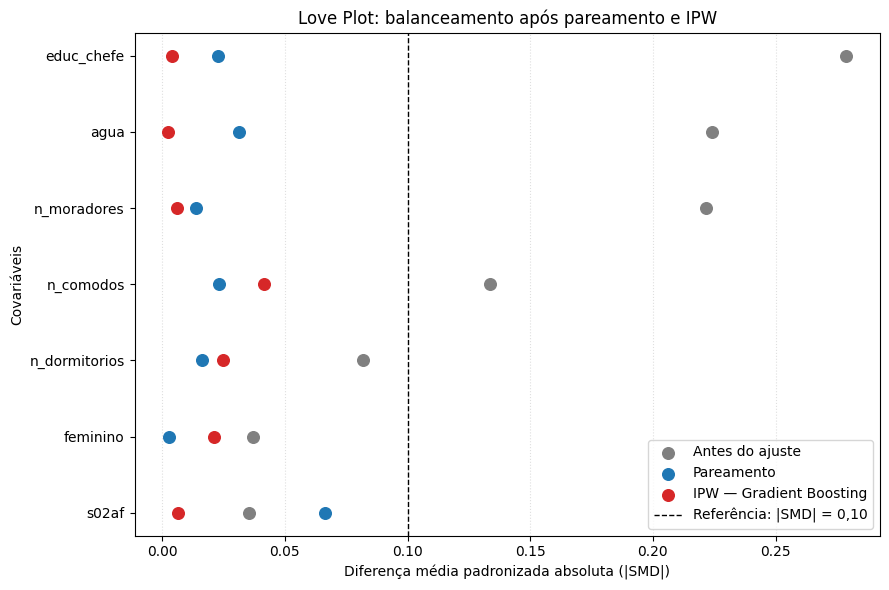

In [14]:
# ============================================================
# LOVE PLOT: PAREAMENTO X IPW
# ============================================================
# Aqui eu comparo visualmente o balanceamento das covariáveis
# antes do ajuste, depois do pareamento pelo propensity score
# e depois do IPW com Gradient Boosting sem calibração.
#
# No eixo horizontal eu mostro a SMD absoluta.
# Quanto mais próximo de zero, melhor o equilíbrio entre
# os grupos tratado e controle.

plt.figure(figsize=(9, 6))

y = np.arange(len(balanceamento))

# Situação antes de qualquer ajuste
plt.scatter(
    balanceamento["Antes"],
    y,
    color="gray",
    s=70,
    label="Antes do ajuste",
    zorder=3
)

# Resultado depois do pareamento
plt.scatter(
    balanceamento["Pareamento"],
    y,
    color="#1f77b4",
    s=70,
    label="Pareamento",
    zorder=3
)

# Resultado depois do IPW sem calibração
plt.scatter(
    balanceamento["IPW sem calibração"],
    y,
    color="#d62728",
    s=70,
    label="IPW — Gradient Boosting",
    zorder=3
)

# Aqui eu marco o valor de referência de 0,10.
# Valores abaixo dessa linha indicam diferenças padronizadas
# relativamente pequenas entre tratados e controles.
plt.axvline(
    x=0.10,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Referência: |SMD| = 0,10"
)

# Organizo os nomes das covariáveis no eixo vertical
plt.yticks(
    y,
    balanceamento["Covariável"]
)

# Inverto o eixo para manter no topo as covariáveis
# que apresentavam maior desequilíbrio antes do ajuste.
plt.gca().invert_yaxis()

plt.xlabel("Diferença média padronizada absoluta (|SMD|)")
plt.ylabel("Covariáveis")
plt.title("Love Plot: balanceamento após pareamento e IPW")

plt.legend()
plt.grid(
    axis="x",
    linestyle=":",
    alpha=0.4
)

plt.tight_layout()
plt.show()

### 3. Balanceamento das covariáveis: pareamento e IPW

O *Love Plot* compara o desequilíbrio das covariáveis antes do ajuste com os resultados obtidos após o pareamento pelo *propensity score* e após a ponderação por IPW com *Gradient Boosting*. O balanceamento foi avaliado pela diferença média padronizada absoluta (|SMD|), de modo que valores mais próximos de zero representam maior semelhança entre os grupos tratado e controle.

Antes do ajuste, quatro das sete covariáveis apresentavam |SMD| superior a 0,10: `educ_chefe`, `agua`, `n_moradores` e `n_comodos`. Após o pareamento, todas as covariáveis ficaram abaixo desse valor de referência, e a média da |SMD| caiu de **0,145** para **0,025**, indicando melhora expressiva no balanceamento.

O IPW com *Gradient Boosting* sem calibração também reduziu todas as diferenças para valores inferiores a 0,10 e apresentou média da |SMD| de **0,015**. Embora o pareamento tenha produzido menor desequilíbrio em algumas covariáveis específicas, o IPW apresentou, no conjunto, diferenças padronizadas mais próximas de zero.

Assim, **ambas as estratégias melhoraram substancialmente o equilíbrio das covariáveis, mas o IPW sem calibração apresentou o melhor balanceamento global**, considerando a magnitude média das diferenças padronizadas. O resultado do IPW calibrado não foi utilizado nessa comparação gráfica porque, conforme identificado anteriormente, uma unidade de controle recebeu *propensity score* igual a 1, gerando um peso extremo e tornando o balanceamento instável.
